## Metabolomics homework
### Ambrus Csaba

### LC–MS metabolomikai pipeline (v2, ST000816)

Lipid peak mátrix: neg + pos ionmód, minták × jellemzők. Lépések a `NMR_Metabolomika_Pipeline_v2.ipynb` szerkezetéhez igazítva: **QC → PQN/log1p/Pareto (+ klasszikus LC–MS előfeldolgozás) → multipanel PCA → univariáns + vulkán → heatmap → PLS-DA + VIP + S-plot → RF**. A függvények a `src/metabolomics_*.py` modulokban vannak.


In [ ]:
# Init gdrive and python environment

from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/csambrus/MetabolKD.git
%cd /content/MetabolKD
!pip install -r ./requirements.txt

In [ ]:
import sys
import traceback
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path("/content/MetabolKD")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
from src.runtime_setup import setup_tensorflow_runtime, setup_notebook_error_logger, set_global_seed

set_global_seed()
setup_notebook_error_logger()
setup_tensorflow_runtime()


## 1. Adatbetöltés (ST000816, baseline — mint a házi feladatban)


In [25]:
from src.download_dataset import download_dataset, combine_pos_neg_to_feature_matrix

data = download_dataset()
X, meta = combine_pos_neg_to_feature_matrix(data)

print("NEG raw:", data["neg"].shape)
print("POS raw:", data["pos"].shape)
print("Feature matrix:", X.shape)
print(meta.head())

# Sample_id (index), progressor_status, visit: egyedi kategóriák száma
cat_counts = {
    "sample_id (index)": meta.index.nunique(),
    "progressor_status": meta["progressor_status"].nunique(dropna=False),
    "visit": meta["visit"].nunique(dropna=False),
}
print("Egyedi kategóriák száma:")
for k, n in cat_counts.items():
    print(f"  {k}: {n}")
for col in ("progressor_status", "visit"):
    print(f"\n{col} — érték szerinti darabszám:")
    print(meta[col].value_counts(dropna=False))

# Visit: hiányzó és szöveges "NA" → Baseline; ezután csak Baseline (Followup kiesik)
meta["visit"] = meta["visit"].replace({"NA": "Baseline", "na": "Baseline"}).fillna("Baseline")

baseline_mask = meta["visit"] == "Baseline"
meta = meta.loc[baseline_mask]
X = X.loc[meta.index]

print(f"Baseline minták: {len(meta)} (X: {X.shape})")
print(meta["visit"].value_counts())

# LC–MS pipeline: a további cellák X_raw néven hivatkoznak a mátrixra
X_raw = X


GDRIVE_DATA: megvan /content/drive/MyDrive/MetabolKD/data/ST000816_AN001293_Results.txt
GDRIVE_DATA: megvan /content/drive/MyDrive/MetabolKD/data/ST000816_AN001294_Results.txt
Másolva → /content/MetabolKD/data/ST000816_AN001293_Results.txt
Másolva → /content/MetabolKD/data/ST000816_AN001294_Results.txt
NEG raw: (162, 101)
POS raw: (413, 101)
Feature matrix: (100, 573)
          progressor_status     visit
sample_id                            
S00017985    Non-progressor  Baseline
S00017986    Non-progressor  Followup
S00017987        Progressor  Baseline
S00017988        Progressor  Followup
S00017989    Non-progressor  Baseline
Egyedi kategóriák száma:
  sample_id (index): 100
  progressor_status: 2
  visit: 3

progressor_status — érték szerinti darabszám:
progressor_status
Non-progressor    50
Progressor        50
Name: count, dtype: int64

visit — érték szerinti darabszám:
visit
NA          60
Baseline    20
Followup    20
Name: count, dtype: int64
Baseline minták: 80 (X: (80, 573))

## 2. QC (mintánkénti összjel és hiányzás)


       total_signal  n_missing  missing_frac
count  8.000000e+01  80.000000     80.000000
mean   1.450142e+08   7.087500      0.012369
std    3.330350e+07   3.409569      0.005950
min    6.200004e+07   0.000000      0.000000
25%    1.238442e+08   5.000000      0.008726
50%    1.446944e+08   7.000000      0.012216
75%    1.703300e+08   9.000000      0.015707
max    2.236135e+08  15.000000      0.026178


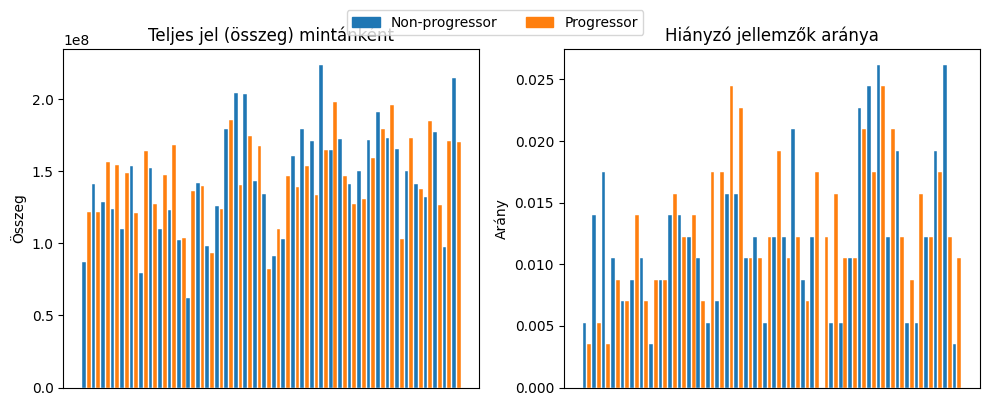

In [14]:
from src.metabolomics_qc import qc_sample_table
from src.metabolomics_plotting import plot_qc_bars

qc = qc_sample_table(X_raw)
print(qc.describe())
fig = plot_qc_bars(qc, meta, hue_col="progressor_status")
fig.savefig("qc_overview.png", dpi=150, bbox_inches="tight")


## 3. NMR-stílusú mátrixok (PQN, log1p, Pareto) + klasszikus LC–MS előfeldolgozás


In [15]:
from src.metabolomics_preprocessing import nmr_style_matrices, preprocess_feature_matrix

blocks = nmr_style_matrices(X_raw, impute_first=True)
for k, df in blocks.items():
    print(k, df.shape)
X_pareto = blocks["X_pareto"]
X_log = blocks["X_log"]

X_proc, steps = preprocess_feature_matrix(X_raw)
print("Klasszikus LC–MS lépések:", " → ".join(steps))
X_proc.head()


X_raw (80, 573)
X_pqn (80, 573)
X_log (80, 573)
X_pareto (80, 573)
Klasszikus LC–MS lépések: median_sample_norm → impute_half_min → log1p → pareto_columns


,neg__CL 70:5; [M-2H](2-)@6.12,neg__CL 74:1; [M-2H](2-)@6.80,neg__CL 74:5; [M-2H](2-)@6.59,neg__CL 74:7; [M-2H](2-)@6.14,neg__CL 78:5; [M-2H](2-)@6.48,neg__CL 82:13; [M-2H](2-)@6.44,neg__CerP 34:1; [M-H]-@5.89,neg__IS PC 34:0;[M-Ac-H]-,neg__IS PE 34:0 ;[M-H]-,neg__IS PG 34:0 ;[M-H]-,...,pos__plasmenyl-PE 36:4; [M+H]+@6.72,pos__plasmenyl-PE 36:5; [M+H]+@6.39,pos__plasmenyl-PE 38:2; [M+H]+@7.92,pos__plasmenyl-PE 38:4; [M+H]+@7.17,pos__plasmenyl-PE 38:5; [M+H]+@5.75,pos__plasmenyl-PE 38:6; [M+H]+@6.66,pos__plasmenyl-PE 40:4; [M+H]+@7.78,pos__plasmenyl-PE 40:5; [M+H]+@7.36,pos__plasmenyl-PE 40:6; [M+H]+@7.23,pos__plasmenyl-PE 42:6; [M+H]+@7.75
sample_id,,,,,,,,,,,,,,,,,,,,,
S00017985,-0.056649,0.549517,-0.853816,-0.333168,0.567393,-0.047831,-0.032609,0.207037,0.226124,0.460968,...,-0.303224,0.632196,-0.284641,-0.123037,-0.324880,0.606609,-0.633068,0.281766,0.366813,-0.404544
S00017987,-0.091050,-0.003848,0.319627,0.039181,0.609764,0.033419,0.006338,-0.581517,-0.463254,-0.550401,...,0.238637,0.330583,-0.415905,0.083487,-0.282215,0.087156,-0.155797,0.172480,0.437013,-0.194538
S00017989,-0.188057,0.335733,-0.239595,-0.131554,-0.348958,-0.314348,-0.231672,0.299410,0.375354,0.149090,...,0.781294,-0.209346,-0.292812,0.370170,-0.024629,-0.018187,0.424732,0.442746,0.131360,0.117713
S00017991,-0.506865,0.771575,-0.506659,-0.304283,0.079430,0.273572,0.263582,0.167796,0.121956,0.411802,...,0.258942,-0.088933,-0.514935,0.279155,-0.264340,-0.040178,-0.328596,-0.032000,0.294271,0.214185
S00017993,0.167618,0.576869,0.867470,0.511845,-0.393220,0.230193,0.285687,-0.089026,0.017502,0.314454,...,0.979717,0.659302,-0.272558,0.946196,0.121404,0.522593,-0.013261,0.646887,0.904807,0.136326


## 4. PCA multipanel (Pareto + log1p térben, extra Z-score nélkül — mint az NMR `X_PARETO`)


Magyarázott variancia (első 5 PC): [0.2047, 0.1307, 0.0821, 0.0671, 0.0386]


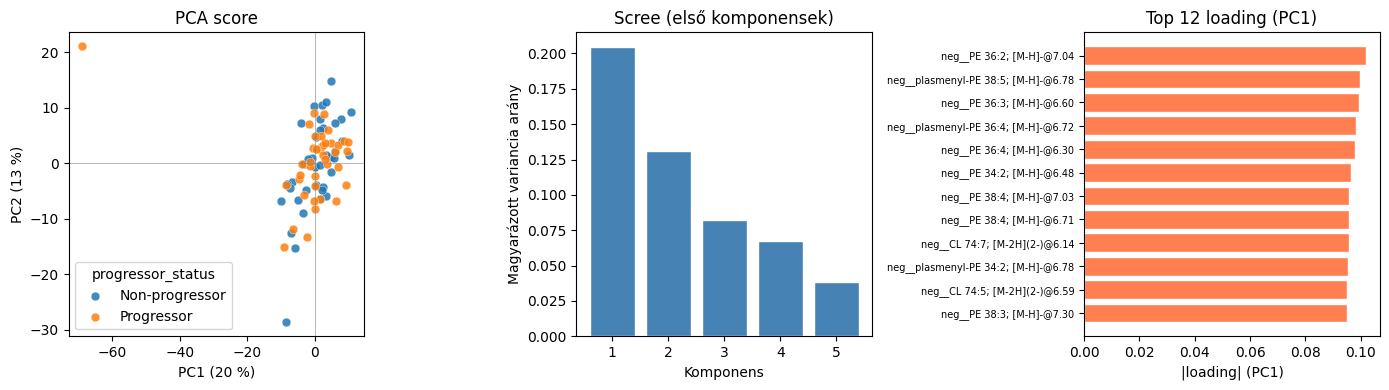

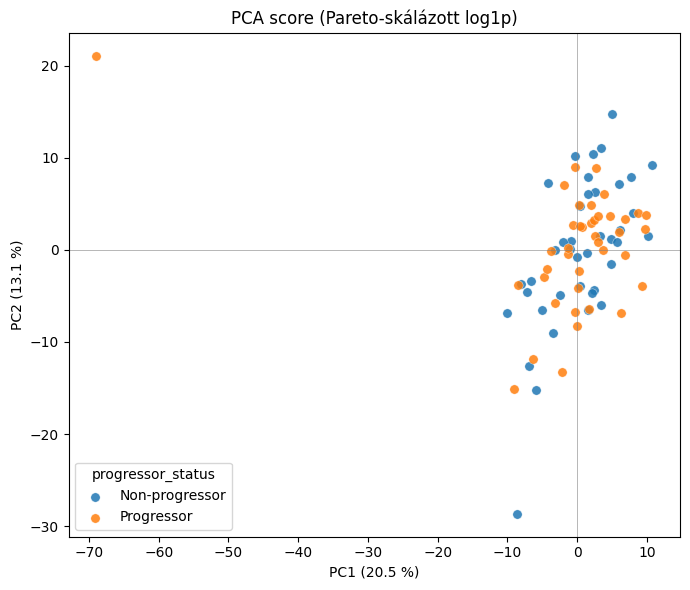

In [16]:
from src.metabolomics_multivariate import fit_pca
from src.metabolomics_plotting import plot_pca_multipanel, plot_pca_scores

pca_out = fit_pca(X_pareto, n_components=5, standardize=False)
scores = pca_out["scores"]
var = pca_out["explained_variance_ratio"]
print("Magyarázott variancia (első 5 PC):", [round(float(v), 4) for v in var])

fig = plot_pca_multipanel(pca_out, meta, hue_col="progressor_status")
fig.savefig("pca_multipanel.png", dpi=150, bbox_inches="tight")

fig2 = plot_pca_scores(
    scores, meta,
    pc_x="PC1", pc_y="PC2",
    hue_col="progressor_status",
    explained=var,
    title="PCA score (Pareto-skálázott log1p)",
)
fig2.savefig("pca_scores.png", dpi=150, bbox_inches="tight")


## 5. Univariáns elemzés + vulkán (Baseline: Progressor vs Non-progressor)


                                 feature  mean_Progressor  \
0                pos__SM 37:1; [M]+@6.73        11.170773   
1            pos__DG 30:2; [M+NH4]+@6.59         7.414519   
2            pos__DG 35:2; [M+NH4]+@7.91         8.274632   
3              pos__PC 37:0; [M+H]+@7.13         9.030303   
4          pos__CE(18:2); [M+NH4]+@12.95         8.333831   
5              pos__PC 38:3; [M+H]+@7.11        14.459939   
6           pos__TG 50:3; [M+NH4]+@10.19        14.410030   
7           pos__TG 52:2; [M+NH4]+@10.65        15.179120   
8           pos__TG 50:2; [M+NH4]+@10.39        14.702694   
9   pos__plasmenyl-PC 40:5; [M+Na]+@7.22         7.547684   
10        pos__lysoPC 16:1; [M+Na]+@1.17         9.305344   
11         pos__lysoPC 20:3; [M+H]+@1.58        12.090996   
12          pos__TG 51:2; [M+NH4]+@10.44        12.484081   
13            pos__TG 50:2; [M+Na]+@9.13         9.060586   
14          pos__TG 52:3; [M+NH4]+@10.46        15.570648   

    mean_Non-progressor

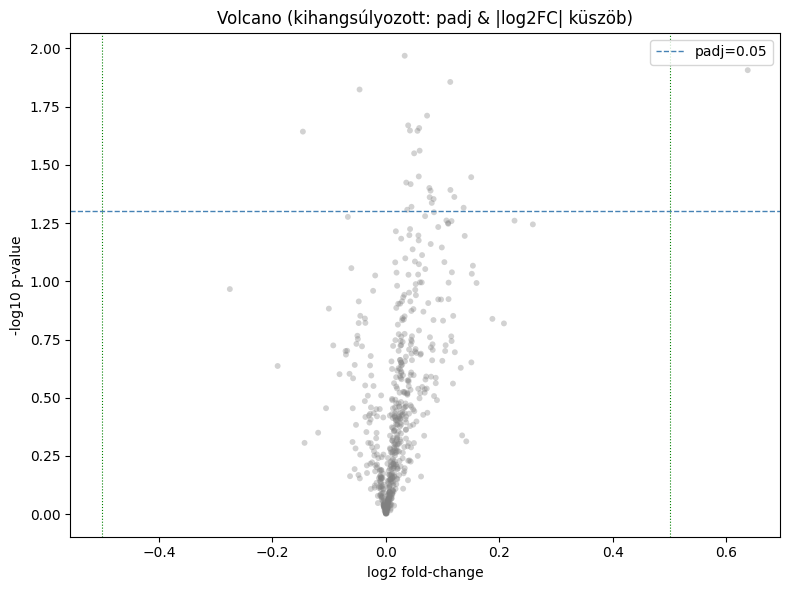

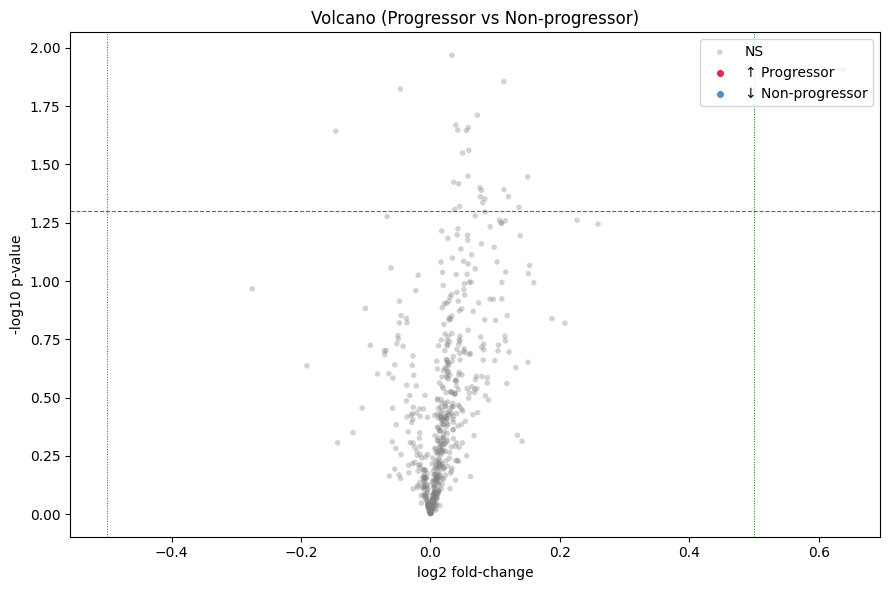

In [17]:
# Csak baseline látogatás
bl = meta["visit"] == "Baseline"
Xb_log = X_log.loc[bl]
Xb_par = X_pareto.loc[bl]
metab = meta.loc[bl]

from src.metabolomics_univariate import differential_analysis
from src.metabolomics_plotting import plot_volcano, plot_volcano_categorized

diff = differential_analysis(
    Xb_log,
    metab["progressor_status"],
    group_a="Progressor",
    group_b="Non-progressor",
    include_cohen_d=True,
)
print(diff.head(15))
fig = plot_volcano(diff, alpha=0.05, fc_thresh=0.5)
fig.savefig("volcano_baseline_progressor.png", dpi=150, bbox_inches="tight")
figc = plot_volcano_categorized(
    diff,
    group_up="Progressor",
    group_down="Non-progressor",
    alpha=0.05,
    fc_thresh=0.5,
)
figc.savefig("volcano_categorized.png", dpi=150, bbox_inches="tight")


## 6. Top eltérések heatmap


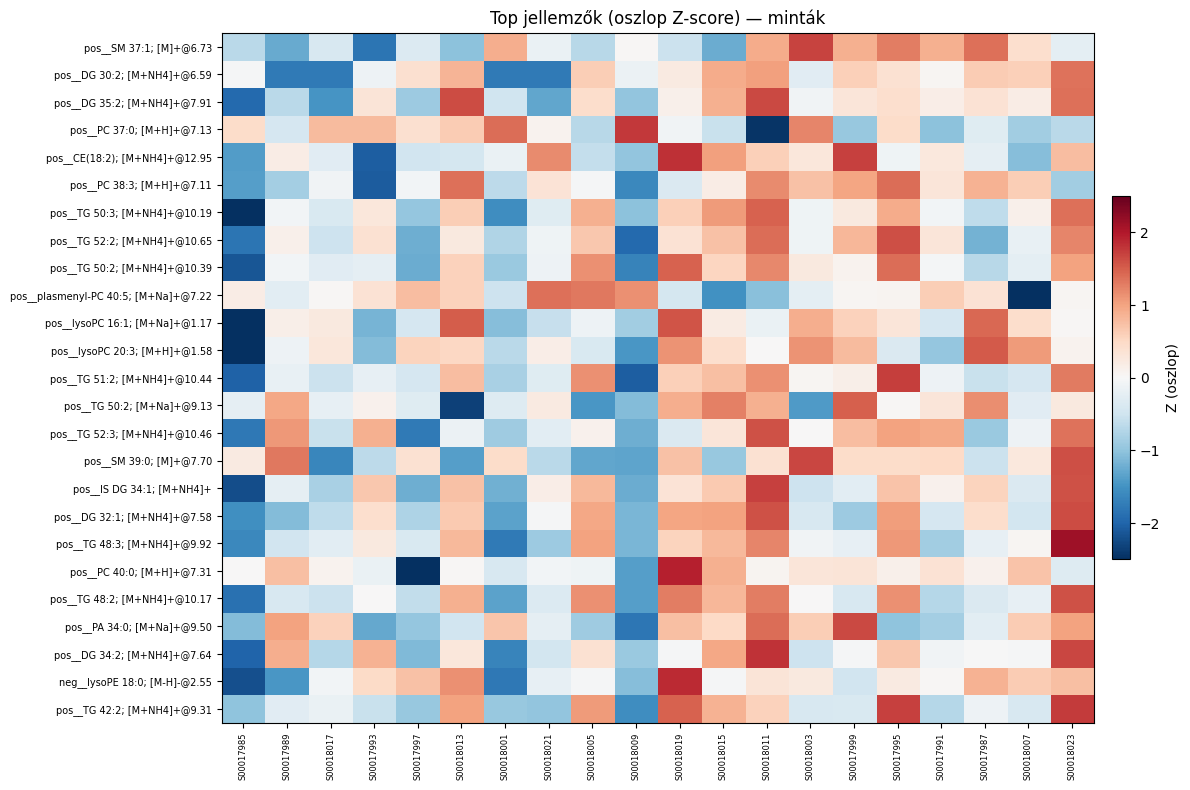

In [18]:
from src.metabolomics_plotting import plot_top_features_heatmap

top_n = 25
top_feats = diff.nsmallest(top_n, "padj")["feature"].tolist()
fig = plot_top_features_heatmap(
    Xb_par,
    top_feats,
    metab,
    group_col="progressor_status",
    max_samples=50,
)
fig.savefig("heatmap_top_features.png", dpi=150, bbox_inches="tight")


## 7. PLS-DA + VIP + S-plot (Pareto mátrix)


pos__SM 37:1; [M]+@6.73                 2.338844
pos__plasmenyl-PC 40:5; [M+Na]+@7.22    1.963934
neg__PC 32:3; [M-Ac-H]-@5.23            1.958257
neg__PE 37:4; [M-H]-@6.74               1.952815
pos__DG 30:2; [M+NH4]+@6.59             1.932251
pos__SM 44:1; [M]+@8.74                 1.929553
pos__TG 50:2; [M+Na]+@9.13              1.777345
neg__IS PG 34:0 ;[M-H]-                 1.753949
pos__PC 42:9; [M+H]+@5.99               1.701469
pos__PC 37:0; [M+H]+@7.13               1.686774
Name: VIP, dtype: float64


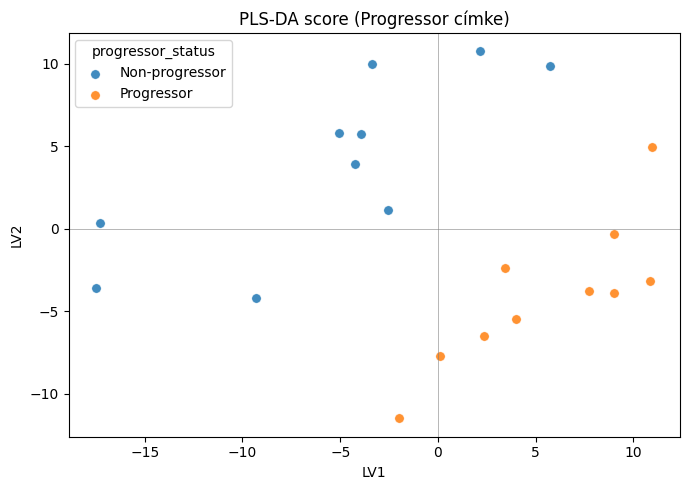

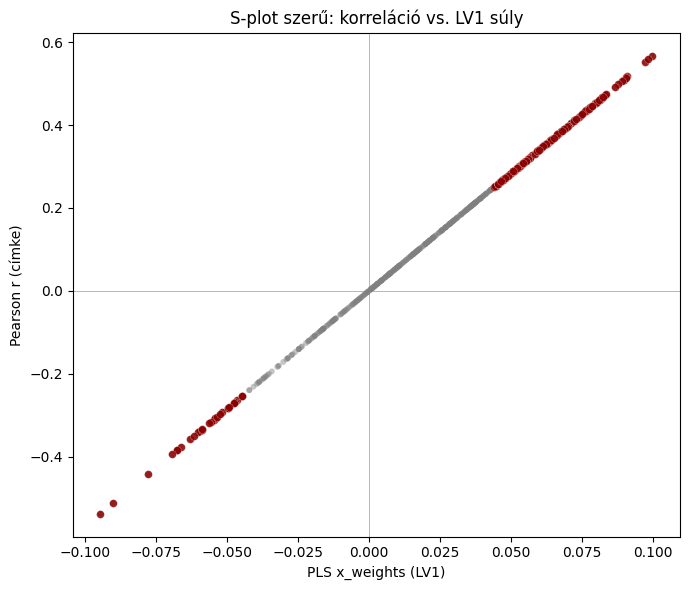

In [19]:
from src.metabolomics_multivariate import fit_plsda_multiclass
from src.metabolomics_plotting import plot_s_plot_lv1
import matplotlib.pyplot as plt

plsda = fit_plsda_multiclass(
    Xb_par,
    metab["progressor_status"],
    n_components=3,
    scale=True,
)
s_pls = plsda["scores"]
vip = plsda["vip"]
print(vip.nlargest(10))

fig, ax = plt.subplots(figsize=(7, 5))
for lab in metab["progressor_status"].unique():
    m = metab["progressor_status"] == lab
    ax.scatter(s_pls.loc[m, "LV1"], s_pls.loc[m, "LV2"], label=str(lab), s=45, alpha=0.85, edgecolors="white", linewidths=0.3)
ax.set_xlabel("LV1")
ax.set_ylabel("LV2")
ax.set_title("PLS-DA score (Progressor címke)")
ax.legend(title="progressor_status")
ax.axhline(0, color="gray", lw=0.4)
ax.axvline(0, color="gray", lw=0.4)
fig.tight_layout()
fig.savefig("plsda_scores.png", dpi=150, bbox_inches="tight")

w1 = plsda["model"].pls.x_weights_[:, 0]
figs = plot_s_plot_lv1(Xb_par, metab["progressor_status"], "Progressor", w1)
figs.savefig("splot_lv1.png", dpi=150, bbox_inches="tight")


## 8. Random Forest — feature importance (felügyelt, gyors)


In [20]:
from src.metabolomics_ml import random_forest_feature_importance

imp = random_forest_feature_importance(
    Xb_par,
    metab["progressor_status"],
    "Progressor",
    n_estimators=300,
)
print(imp.head(20))


neg__PE 38:3; [M-H]-@6.46               0.024397
pos__TG 50:2; [M+Na]+@9.13              0.020107
pos__CE(18:2); [M+NH4]+@12.95           0.015458
pos__PC 40:0; [M+H]+@7.31               0.013848
pos__TG 51:2; [M+NH4]+@10.44            0.013768
pos__DG 35:2; [M+NH4]+@7.91             0.013016
neg__PC 33:2; [M-Ac-H]-@6.03            0.012123
pos__plasmenyl-PC 44:4; [M+Na]+@8.11    0.011838
pos__lysoPC 16:1; [M+Na]+@1.17          0.011104
pos__SM 36:0; [M]+@6.80                 0.011102
pos__PC 36:8; [M+H]+@5.17               0.010664
pos__PC 38:3; [M+H]+@7.11               0.010193
pos__DG 36:3; [M+NH4]+@7.76             0.009772
pos__SM 36:1; [M]+@6.51                 0.009641
pos__TG 58:8; [M+NH4]+@10.40            0.009234
neg__plasmenyl-PE 34:0; [M-H]-@7.29     0.009192
pos__TG 42:0; [M+NH4]+@9.83             0.009067
pos__TG 42:2; [M+NH4]+@9.31             0.008556
neg__PE 36:0; [M-H]-@7.89               0.008066
pos__TG 42:1; [M+NH4]+@9.60             0.007834
Name: importance, dt

## 9. Rövid értelmezés

- **QC**: extrém `total_signal` vagy `missing_frac` minták kiszűrhetők.
- **PCA**: fő irányok a legnagyobb közös variancia mentén; színezés a klinikai címkével.
- **Vulkán + FDR**: egyszerre nézünk hatást (log2FC) és bizonytalanságot (p / FDR).
- **PLS-DA + VIP + S-plot**: felügyelt irányok és jellemző-súlyok (NMR notebook mintájára).
- **RF importance**: nemlineáris alternatíva a fontos peak-ekhez.

A `NMR_Metabolomika_Pipeline_v2.ipynb` referenciához igazítva: **PQN / log1p / Pareto**, **multipanel PCA**, **FDR (statsmodels BH)**, **kategorizált vulkán**, **PLS-DA + VIP**; GPU/SHAP részek nélkül, LC–MS lipid adatra.

